# Training 3 different RNNs

In this notebook I will train 3 different RNNs, one simple RNN, one LSTM and one GRU.

In [1]:
import numpy as np
import pandas as pd
import os
import random
from RNN_models import *
import torch
from torch import optim
from torchinfo import summary


device = torch.device("cpu")

data_folder = "../../MainProject/data/mediapipe_ugly_recordings"
n_frames = 30
n_features = 66

print(device)

cpu


In [ ]:
def load_array(data_path, n_frames=30, n_features=66) -> tuple[torch.tensor, torch.tensor]:
    """
    Loads a csv-file and reshapes it into (n_frames, n_features)

    Args:
        data_path: Path to the data to load
        n_frames: How many rows of data to use in shaping
        n_features: How many columns of data to use in shaping
    
    Returns:
        X, Y: The data in shape (n_frames, n_features), The target as a 1darray
    """
    data = pd.read_csv(data_path)
    y = data["target"].values - 1
    x = data.drop(columns=["target"]).values
    return torch.tensor(x.reshape(n_frames, n_features), dtype=torch.float32), torch.tensor(y, dtype=torch.int)


def split_csvfiles(datafolder, random_seed, training_prop, validation_prop):
    csv_files = []
    for f in os.listdir(datafolder):
        if f.endswith(".csv"):
            csv_files.append(f)

    random.seed(random_seed)
    random.shuffle(csv_files)

    train_n = int(len(csv_files) * training_prop)
    val_n = int(len(csv_files) * validation_prop)

    # Split
    if validation_prop == 0:
        train_files = csv_files[:train_n]
        test_files = csv_files[train_n:]

        return train_files, test_files

    else:
        train_files = csv_files[:train_n]
        val_files = csv_files[train_n: train_n + val_n]
        test_files = csv_files[train_n + val_n:]

        return train_files, val_files, test_files

In [ ]:
from sklearn.preprocessing import StandardScaler
train_files, test_files = split_csvfiles(data_folder, random_seed=42, training_prop=0.9, validation_prop=0)

# Training Data Preparation
training_data = []
for index, file in enumerate(train_files):
    path = os.path.join(data_folder, file)
    x, y = load_array(path)

    scaler = StandardScaler()
    scaler.fit(x)
    x = torch.tensor(scaler.transform(x).reshape(-1, n_frames, n_features), dtype=torch.float32).to(device)
    y = y.to(device)

    training_data.append((x, y))

# Test Data Preparation
test_data = torch.zeros((len(test_files), 30, 66))
true_labels = torch.zeros(len(test_files))
for index, file in enumerate(test_files):
    path = os.path.join(data_folder, file)
    x, y = load_array(path)
    test_data[index, :, :] = x
    true_labels[index] = y

print(f"Total numer of files to train on: {len(train_files)}")
print(f"Total number of files to test on: {len(test_files)}")

Total numer of files to train on: 182
Total number of files to test on: 21


### Initialize the models

In [4]:
from sklearn.model_selection import KFold
from torch.utils.data import Subset, DataLoader
import copy


def train_model(params: dict, training_data: tuple, n_folds: int = 5) -> tuple[nn.Module, dict]:
    """
    Train model with validation and optional cross-validation

    Args:
        params: Training parameters
        training_data: Tuple of (X, Y) data
        n_folds: Number of folds for cross-validation (default: 5)
    """

    # Compute weights of the labels to counteract an imbalanced dataset
    occurences = {}
    total = 0
    for X, Y in training_data:
        Y = int(Y)
        if Y in occurences:
            occurences[Y] += 1
        else:
            occurences[Y] = 1
        total += 1

    class_weights = torch.tensor([total / (len(occurences) * occurences[i]) for i in range(len(occurences))])

    results = {}

    # Perform k-fold cross-validation
    print(f"\nPerforming {n_folds}-fold cross-validation...")
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

    fold_results = []
    fold_models = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(training_data)):
        print(f"\n--- Fold {fold + 1}/{n_folds} ---")

        # Split data
        train_fold = [training_data[i] for i in train_idx]
        val_fold = [training_data[i] for i in val_idx]

        # Train on this fold
        model, fold_stats = train_single_model(
            params, train_fold, val_fold, class_weights, fold_num=fold + 1
        )

        fold_results.append(fold_stats)
        fold_models.append(model)

    # Aggregate cross-validation results
    results = aggregate_cv_results(fold_results)
    results['fold_models'] = fold_models
    results['cv_scores'] = [stats['final_val_accuracy'] for stats in fold_results]
    results['mean_cv_accuracy'] = np.mean(results['cv_scores'])
    results['std_cv_accuracy'] = np.std(results['cv_scores'])

    # Train final model on all data
    print("\n--- Training final model on all data ---")
    final_model, final_stats = train_single_model(
        params, training_data, None, class_weights, is_final=True
    )
    results['final_model'] = final_model
    results['final_stats'] = final_stats

    return final_model, results


def train_single_model(params: dict, train_data: list, val_data: list = None, 
                       class_weights: torch.Tensor = None, fold_num: int = None, 
                       is_final: bool = False) -> tuple[nn.Module, dict]:
    """Train a single model with optional validation"""

    model = params["model_type"](
        params["input_size"], 
        params["hidden_size"], 
        params["depth"], 
        params["num_of_classification_labels"]
    ).to(device)

    optimizer = params["optimizer"](model.parameters(), lr=params["lr"])
    loss_func = nn.CrossEntropyLoss(weight=class_weights.to(device)).to(device)

    prev_loss = np.inf
    streak = 0
    loss_increase = False
    loss_history = []
    val_loss_history = []
    val_accuracy_history = []
    early_stopping = False

    prefix = f"Fold {fold_num}" if fold_num else "Final" if is_final else "Model"
    print(f"{prefix} training with {params['epochs']} epochs")
    print("Start", " " * 10, "Finished")
    print("v", " " * 21, "v")

    interval = max(1, params["epochs"] // 25)

    for epoch in range(params["epochs"]):
        # Training phase
        model.train()
        total_loss = 0

        for X, Y in train_data:

            output = model(X)
            loss = loss_func(output, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_data)
        loss_history.append(avg_loss)

        # Validation phase
        if val_data:
            model.eval()
            val_loss = 0
            correct = 0
            total_samples = 0

            with torch.no_grad():
                for X, Y in val_data:
                    output = model(X.unsqueeze(0) if X.dim() == 1 else X)
                    loss = loss_func(output, y)
                    val_loss += loss.item()

                    # Calculate accuracy
                    _, predicted = torch.max(output, 1)
                    correct += (predicted == y).sum().item()
                    total_samples += 1

            avg_val_loss = val_loss / len(val_data)
            val_accuracy = correct / total_samples
            val_loss_history.append(avg_val_loss)
            val_accuracy_history.append(val_accuracy)

            # Early stopping based on validation loss
            if avg_val_loss > prev_loss:
                loss_increase = True
            else:
                loss_increase = False
                # Save best model based on validation loss
                if not is_final:
                    best_model_state = copy.deepcopy(model.state_dict())

            if loss_increase:
                streak += 1
            else:
                streak = 0

            prev_loss = avg_val_loss
        else:
            # Early stopping based on training loss
            if avg_loss > prev_loss:
                loss_increase = True
            else:
                loss_increase = False

            if loss_increase:
                streak += 1
            else:
                streak = 0

            prev_loss = avg_loss

        # Early stopping check
        if streak >= params.get("patience", 5):
            early_stopping = True
            print(f"\nEarly stopping at epoch {epoch + 1}")
            break

        # Progress indicator
        if epoch % interval == 0:
            print("#", end="", flush=True)

    print()  # New line after progress indicators

    # Load best model if validation was used
    if val_data and not is_final and 'best_model_state' in locals():
        model.load_state_dict(best_model_state)

    # Calculate final validation metrics
    final_val_accuracy = val_accuracy_history[-1] if val_accuracy_history else None
    best_val_accuracy = max(val_accuracy_history) if val_accuracy_history else None

    stats = {
        "loss_history": loss_history,
        "val_loss_history": val_loss_history,
        "val_accuracy_history": val_accuracy_history,
        "final_val_accuracy": final_val_accuracy,
        "best_val_accuracy": best_val_accuracy,
        "early_stopping": early_stopping,
        "n_epochs_trained": len(loss_history)
    }

    return model, stats


def aggregate_cv_results(fold_results: list) -> dict:
    """Aggregate results from cross-validation folds"""

    aggregated = {
        "cv_fold_results": fold_results,
        "val_accuracies": [r['final_val_accuracy'] for r in fold_results if r['final_val_accuracy']],
        "best_val_accuracies": [r['best_val_accuracy'] for r in fold_results if r['best_val_accuracy']],
        "n_epochs_per_fold": [r['n_epochs_trained'] for r in fold_results]
    }

    if aggregated['val_accuracies']:
        aggregated['mean_val_accuracy'] = np.mean(aggregated['val_accuracies'])
        aggregated['std_val_accuracy'] = np.std(aggregated['val_accuracies'])

    if aggregated['best_val_accuracies']:
        aggregated['mean_best_accuracy'] = np.mean(aggregated['best_val_accuracies'])

    print("\n" + "="*50)
    print("Cross-Validation Results:")
    print(f"  Mean validation accuracy: {aggregated['mean_val_accuracy']:.4f} ± {aggregated['std_val_accuracy']:.4f}")
    print(f"  Mean best accuracy: {aggregated['mean_best_accuracy']:.4f}")
    print(f"  Mean epochs trained: {np.mean(aggregated['n_epochs_per_fold']):.1f}")
    print("="*50)

    return aggregated

### Train the three models

In [5]:
models = []
models_stats = []

params_RNN = {
    "model_type": SimpleRNNModel,
    "input_size": 66,
    "hidden_size": 32,
    "depth": 5,
    "num_of_classification_labels": 3,
    "lr": 0.001,
    "optimizer": optim.Adam,
    "patience": 3,
    "epochs": 100
}
RNN, RNN_stats = train_model(params=params_RNN, training_data=training_data)
models.append(RNN)
models_stats.append(RNN_stats)

print(f"The final loss achieved: {RNN_stats["final_stats"]["loss_history"][-1]}")
model_summary = summary(RNN)
print(model_summary)


Performing 5-fold cross-validation...

--- Fold 1/5 ---
Fold 1 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 2/5 ---
Fold 2 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 3/5 ---
Fold 3 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 4/5 ---
Fold 4 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 5/5 ---
Fold 5 training with 100 epochs
Start            Finished
v                       v
#########################

Cross-Validation Results:
  Mean validation accuracy: 1.0000 ± 0.0000
  Mean best accuracy: 1.0000
  Mean epochs trained: 100.0

--- Training final model on all data ---
Final training with 100 epochs
Start            Finished
v                       v
#########################
The final loss achieved: 0.0
Layer (type:

In [6]:
params_LSTM = {
    "model_type": LSTMModel,
    "input_size": 66,
    "hidden_size": 16,
    "depth": 5,
    "num_of_classification_labels": 3,
    "lr": 0.0001,
    "optimizer": optim.Adam,
    "patience": 3,
    "epochs": 100
}
LSTM, LSTM_stats = train_model(params=params_LSTM, training_data=training_data)
models.append(LSTM)
models_stats.append(LSTM_stats)

print(f"The final loss achieved: {LSTM_stats["final_stats"]["loss_history"][-1]}")
model_summary = summary(LSTM)
print(model_summary)


Performing 5-fold cross-validation...

--- Fold 1/5 ---
Fold 1 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 2/5 ---
Fold 2 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 3/5 ---
Fold 3 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 4/5 ---
Fold 4 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 5/5 ---
Fold 5 training with 100 epochs
Start            Finished
v                       v
#########################

Cross-Validation Results:
  Mean validation accuracy: 1.0000 ± 0.0000
  Mean best accuracy: 1.0000
  Mean epochs trained: 100.0

--- Training final model on all data ---
Final training with 100 epochs
Start            Finished
v                       v
#########################
The final loss achieved: 1.39252071406460

In [7]:
params_GRU = {
    "model_type": GRUModel,
    "input_size": 66,
    "hidden_size": 16,
    "depth": 5,
    "num_of_classification_labels": 3,
    "lr": 0.0001,
    "optimizer": optim.Adam,
    "patience": 3,
    "epochs": 50
}
GRU, GRU_stats = train_model(params=params_GRU, training_data=training_data)
models.append(GRU)
models_stats.append(GRU_stats)

print(f"The final loss achieved: {GRU_stats["final_stats"]["loss_history"][-1]}")
model_summary = summary(GRU)
print(model_summary)


Performing 5-fold cross-validation...

--- Fold 1/5 ---
Fold 1 training with 50 epochs
Start            Finished
v                       v
#########################

--- Fold 2/5 ---
Fold 2 training with 50 epochs
Start            Finished
v                       v
#########################

--- Fold 3/5 ---
Fold 3 training with 50 epochs
Start            Finished
v                       v
#########################

--- Fold 4/5 ---
Fold 4 training with 50 epochs
Start            Finished
v                       v
#########################

--- Fold 5/5 ---
Fold 5 training with 50 epochs
Start            Finished
v                       v
#########################

Cross-Validation Results:
  Mean validation accuracy: 1.0000 ± 0.0000
  Mean best accuracy: 1.0000
  Mean epochs trained: 50.0

--- Training final model on all data ---
Final training with 50 epochs
Start            Finished
v                       v
#########################
The final loss achieved: 0.00023281874986183778


### Visualize the training

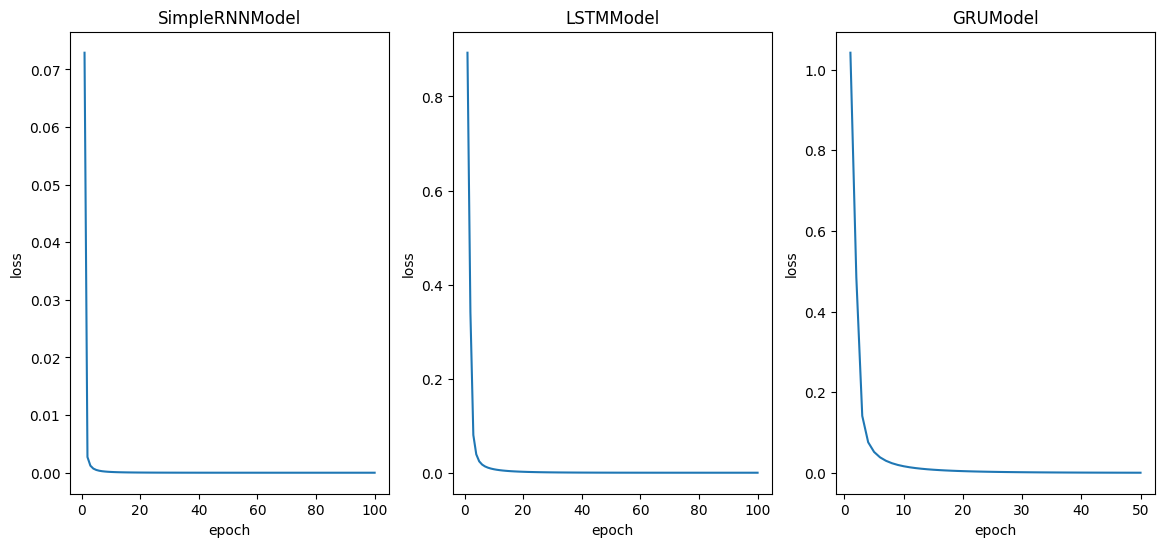

In [8]:
from matplotlib import pyplot as plt

fig, axs = plt.subplots(1, len(models), figsize=[14, 6])

for i, stats in enumerate(models_stats):
    if len(models) > 1:
        ax = axs[i]
    else:
        ax = axs
    ax.set_title(models[i].to_string())
    ax.plot([i for i in range(1, len(stats["final_stats"]["loss_history"]) + 1)], stats["final_stats"]["loss_history"])
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")

plt.show()

### Predict and evaluate

Model 0: SimpleRNNModel
Predictions: tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=torch.int32)
True labels: tensor([2., 2., 1., 2., 1., 2., 2., 2., 2., 0.])


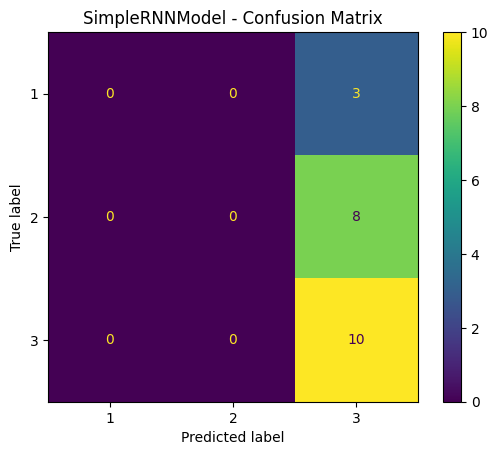

Model 1: LSTMModel
Predictions: tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=torch.int32)
True labels: tensor([2., 2., 1., 2., 1., 2., 2., 2., 2., 0.])


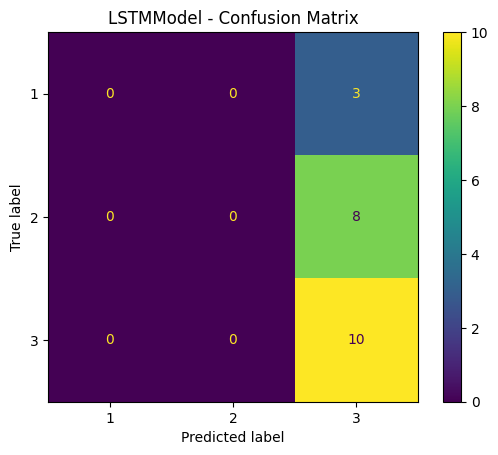

Model 2: GRUModel
Predictions: tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=torch.int32)
True labels: tensor([2., 2., 1., 2., 1., 2., 2., 2., 2., 0.])


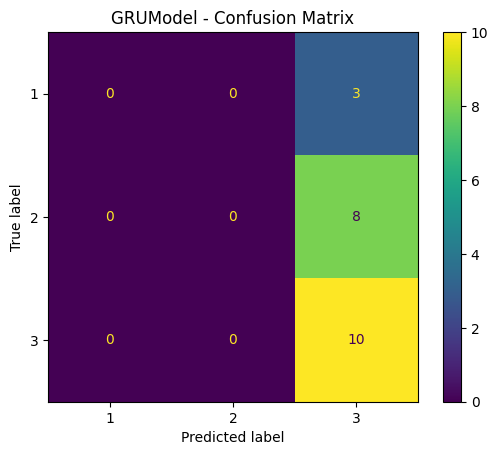

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for i, model in enumerate(models):
    model.eval()
    with torch.no_grad():
        predictions = model(test_data).argmax(dim=1).int()

        print(f"Model {i}: {model.to_string()}")
        print(f"Predictions: {predictions[:10]}")
        print(f"True labels: {true_labels[:10]}")

        # Confusion matrix
        cm = confusion_matrix(true_labels, predictions)

        disp = ConfusionMatrixDisplay(cm, display_labels=['1', '2', '3'])
        disp.plot()
        plt.title(f"{models[i].to_string()} - Confusion Matrix")
        plt.show()

### Save model

In [23]:
for i, model in enumerate(models):
    path = model.to_string() + ".pth"
    torch.save(model, f"../models/RNN_models/{path}")
    print(f"Saved model {model.to_string()} to {path}")

Saved model SimpleRNNModel to SimpleRNNModel.pth
Saved model LSTMModel to LSTMModel.pth
Saved model GRUModel to GRUModel.pth
